In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import great_tables
from great_tables import GT, md, html
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib import pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.factorplots import interaction_plot
from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr
from config import *

In [10]:
data =  pd.read_excel(r"Results_isofys\data_for_R.xlsx") #work with the most updated and cleaned database
data = data.drop(columns = ["Unnamed: 0"])
data['Plot'] = data["Plot"].astype("category")
data['TreeID'] = data["TreeID"].astype("category")
#data['code'] = data["code"].astype("category")
data["Sub"] = data["Sub"].astype("category")
data["name"] = data["name"].astype("category")
data["Site"] = data["Site"].astype("category")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Plot                        182 non-null    category      
 1   TreeID                      182 non-null    category      
 2   Sub                         182 non-null    category      
 3   name                        182 non-null    category      
 4   genus                       87 non-null     object        
 5   specie                      182 non-null    object        
 6   Site                        182 non-null    category      
 7   [C_b]                       182 non-null    float64       
 8   bulk_δ13C (‰ v.s.V-PDB)     182 non-null    float64       
 9   [N]                         181 non-null    float64       
 10  δ15N (‰ v.s.AIR)            182 non-null    float64       
 11  [O]                         182 non-null    float64       

In [11]:
table = data.groupby(['elevation_m', 'name', 'Sub']).size().unstack(fill_value=0)
table = table[table["C"]!=0].reset_index()
# Optional: rename columns for clarity
table.columns.name = None
table.rename(columns={"C":"C", "P":"P", "NP":"NxP"}, inplace=True)
table



,elevation_m,name,C,N,NxP,P
0,1000,Clarisia racemosa,3,1,4,4
1,1000,Pouteria torta,11,10,7,8
2,2000,Alchornea lojaensis,12,10,8,15
3,2000,Myrcia sp nov,15,10,13,12
4,3000,Hedyosmun purpurascens,5,6,3,7
5,3000,Weinmania loxensis,5,5,2,6


In [12]:

def table_summary(df):
    """This code do the last cleaning up of my database"""
    main = ["name","Sub","elevation_m",named13C_cellulose,iWUE,SLA,"LCC","LNC","LPC","N:P","C:N"]
    secondary = ["name","Sub","elevation_m",named13C_cellulose,iWUE,SLA,"C_area","N_area","P_area"]
    data = df[main]
   # columskeep = []
    description = data.groupby(["elevation_m",'name', 'Sub']).agg(["mean","std"]).round(2).dropna(how="all")
   # Get the name of the first numeric column
    first_numeric = data.select_dtypes("number").columns[0]
   # Keep only one 'count' column + all mean/std columns
    description = pd.concat([
    #description.loc[:, (first_numeric, "count")],
    description.loc[:, pd.IndexSlice[:, ["mean", "std"]]]
       ], axis=1)
    # Sort by elevation
    
    #description = description.sort_values("elevation_m", ascending=True)
    description.to_excel("Summary.xlsx")
    print("Summary created and exported to Excel file")
    return description

table_summary(data) #HELP Define que necesitamos

NameError: name 'iWUE' is not defined

In [ ]:
import config
from config import * #Here we use the standarized variables names for easines

var = name18O #### aqui definimos para analizar en todos los siguientes

### Overall pairplot 
Here are all the included traits. SF is not complete


In [ ]:
iWUE = "iWUE (μmol/mol)"
columns = [iWUE,thick,though,LTA,SLA,leaf_water]
SLA = 'Specific leaf area (cm²/g)'
# I want to see the iWUE agains the functional traits 
#sns.pairplot(
#    data=data,
#    vars=columns, 
#    hue = "elevation_m",  
#    #kind = "reg",
#    corner = True
#)
#plt.tight_layout()
#plt.show()



In [ ]:
data.dtypes

Plot                                category
TreeID                              category
Sub                                 category
name                                category
genus                                 object
specie                                object
Site                                category
[C_b]                                float64
bulk_δ13C (‰ v.s.V-PDB)              float64
[N]                                  float64
δ15N (‰ v.s.AIR)                     float64
[O]                                  float64
δ18O in ‰ vs DeltaSMOW               float64
[C]                                  float64
δ13C (‰ v.s.V-PDB)                   float64
height_2024                          float64
force to punch (kN/m)                float64
thickness (mm)                       float64
Leaf fresh weight (g)                float64
Leaf dry weight (g)                  float64
Leaf area (cm²)                      float64
area_basal_m2                        float64
Sampling d

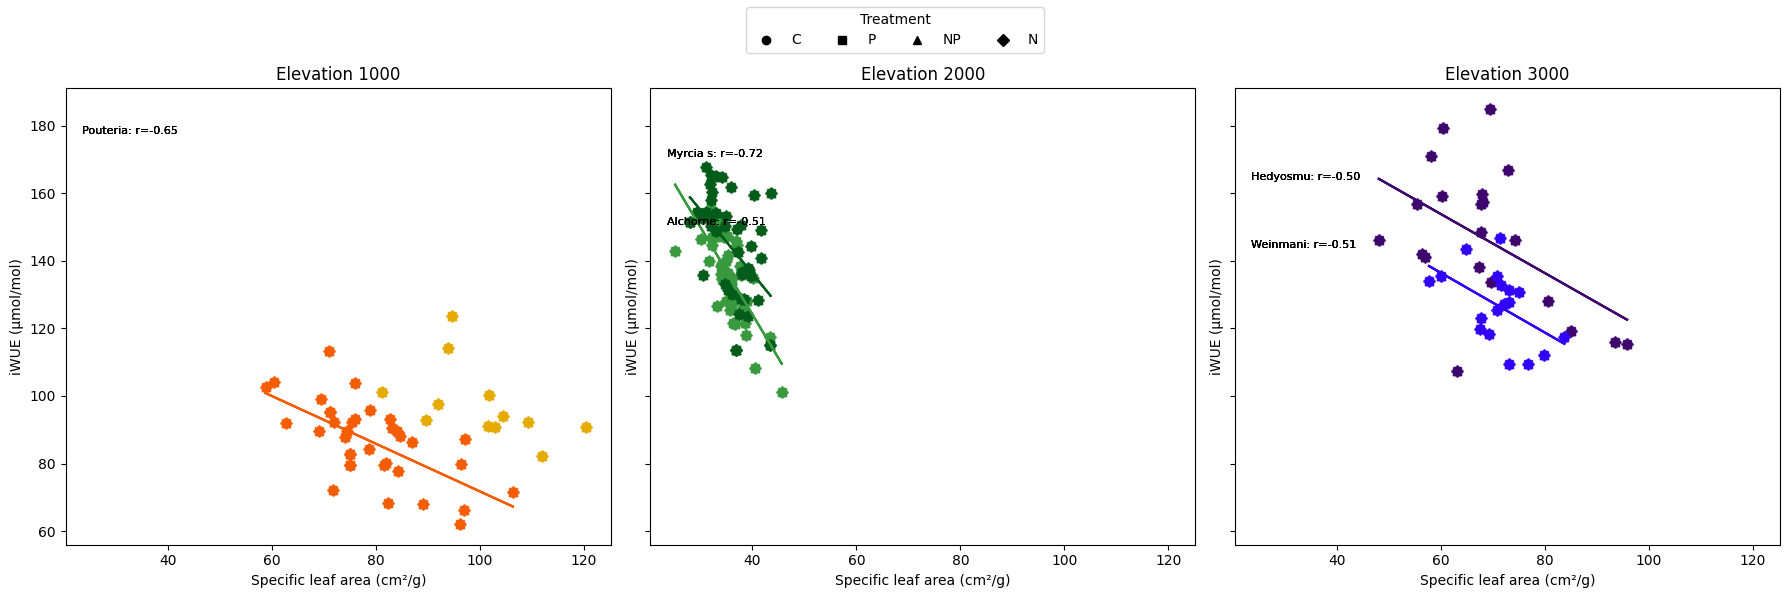

In [ ]:
def relation_nutrients_iWUE_1x3(df, x, y):

    subs = ['C', 'P', 'NP', 'N']

    species_order = [
        "Pouteria torta",
        "Myrcia sp nov",
        "Hedyosmun  purpurascens",
        "Clarisia  racemosa",
        "Alchornea lojaensis",
        "Weinmania  loxensis"
    ]

    palette_species = {
        "Pouteria torta": "#f55d05",
        "Clarisia  racemosa": "#e6ab02",
        "Myrcia sp nov": "#39993e",
        "Alchornea lojaensis": "#045C1A",
        "Weinmania  loxensis": "#3002fc",
        "Hedyosmun  purpurascens": "#3e056d",
    }

    markers = ['o', 's', '^', 'D']
    marker_map = dict(zip(subs, markers))

    elevations = sorted(df["elevation_m"].dropna().unique())

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(elevations),
        figsize=(18,6),
        sharex=True,
        sharey=True
    )

    for i, elev in enumerate(elevations):

        ax = axes[i]
        df_elev = df[df["elevation_m"] == elev]

        for sp in species_order:

            for sub in subs:

                data_sub = df_elev[(df_elev['name'] == sp)][[x,y]].dropna()
                if len(data_sub) < 2:
                    continue

                xvals = data_sub[x]
                yvals = data_sub[y]

                r, p = pearsonr(xvals, yvals)

                # Only show significant correlations

                ax.scatter(
                        xvals,
                        yvals,
                        color=palette_species[sp],
                        marker=marker_map[sub],
                        alpha=0.8
                    )

                    
                if p < 0.05:

                    ax.text(
                        0.03,
                        0.9 - 0.05*(species_order.index(sp)),
                        f"{sp[:8]}: r={r:.2f}",
                        transform=ax.transAxes,
                        fontsize=8
                    )

                    # regression line
                    m, b = np.polyfit(xvals, yvals, 1)
                    xs = np.array([xvals.min(), xvals.max()])
                    ys = m * xs + b

                    ax.plot(
                        xs,
                        ys,
                        color=palette_species[sp],
                        linewidth=1.5
                    )

        ax.set_title(f"Elevation {elev}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    # legend for treatments (shapes)
    shape_handles = [
        plt.Line2D([0],[0],
                   marker=marker_map[sub],
                   linestyle="",
                   color="black",
                   label=sub)
        for sub in subs
    ]

    fig.legend(handles=shape_handles,
               loc="upper center",
               ncol=len(subs),
               title="Treatment")

    plt.tight_layout(rect=[0,0,1,0.92])
    plt.show()


relation_nutrients_iWUE_1x3(data, SLA, iWUE)

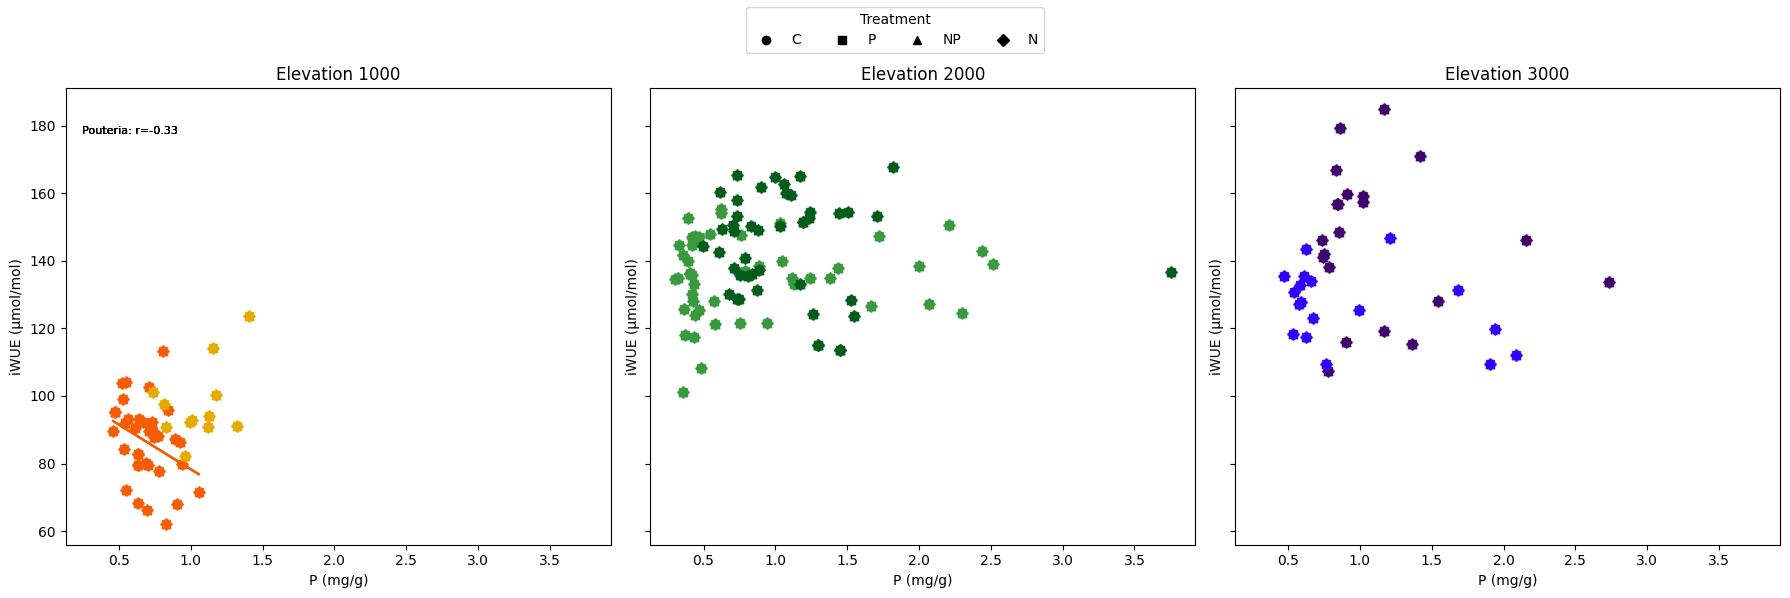

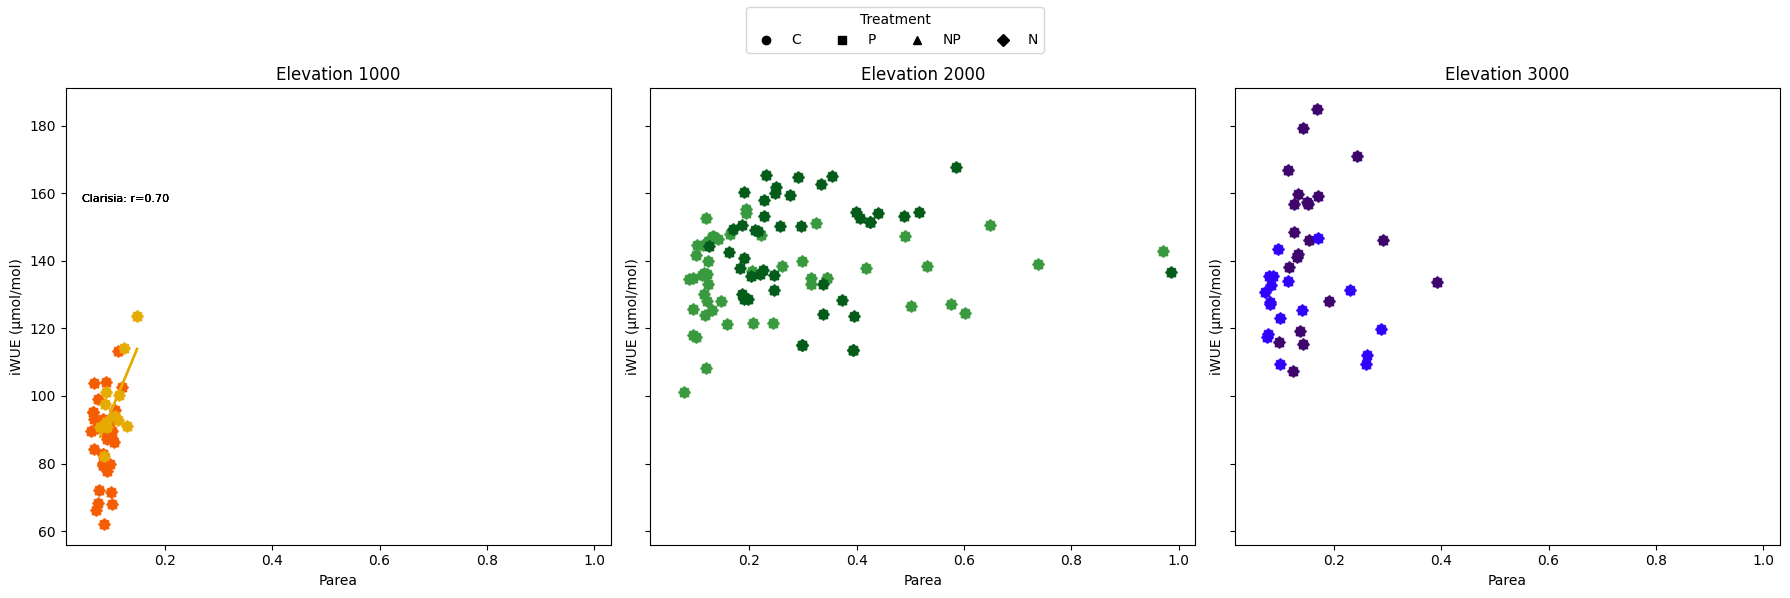

In [ ]:
data["Parea"] = data["P (mg/g)"]*(1/data[SLA])*(10)
data["N:P"] = data["P (mg/g)"]/(data["[N]"]*100)#HELP: Revisar unidades

relation_nutrients_iWUE_1x3(data, "P (mg/g)", iWUE)
relation_nutrients_iWUE_1x3(data, "Parea", iWUE)

In [ ]:
data.dtypes

Plot      category
TreeID    category
Sub       category
name      category
genus       object
            ...   
C_area     float64
P_area     float64
C:P        float64
N:P        float64
Parea      float64
Length: 61, dtype: object

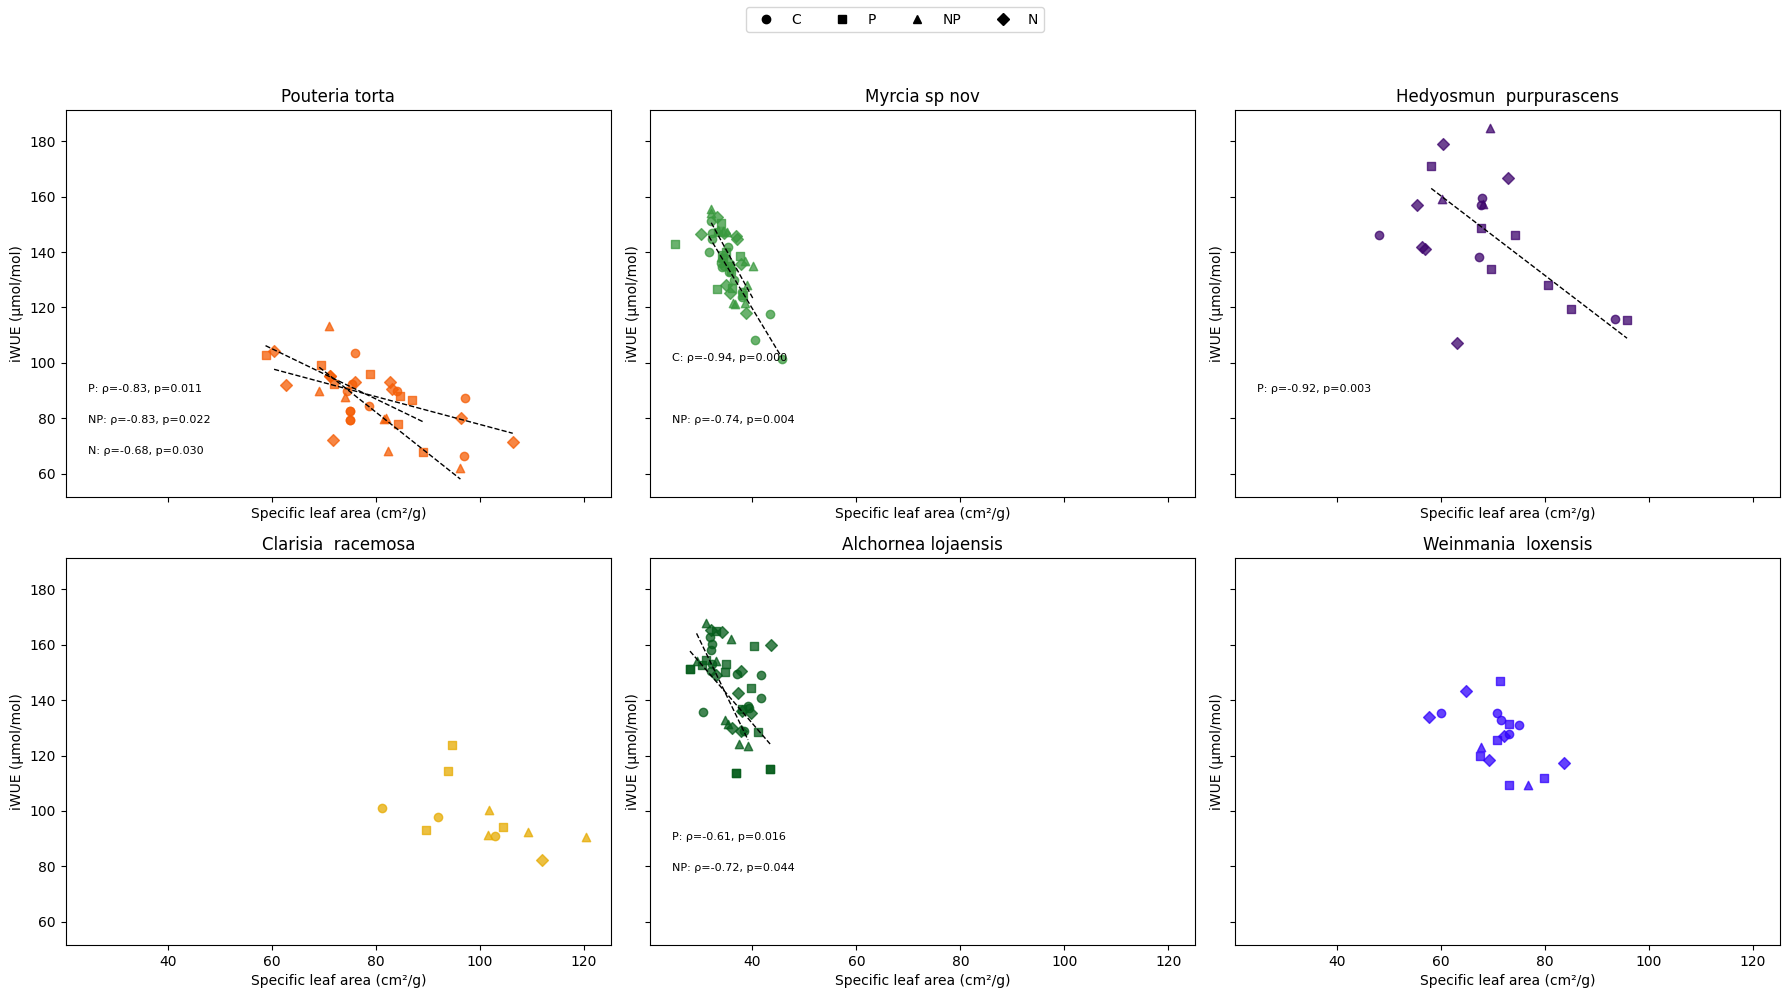

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import itertools


def relation_nutrients_iWUE_2x3(df, x, y):
    subs = ['C', 'P', 'NP', 'N']

    # Species order (explicit)
    species_order = [
        "Pouteria torta",
        "Myrcia sp nov",
        "Hedyosmun  purpurascens",
        "Clarisia  racemosa",
        "Alchornea lojaensis",
        "Weinmania  loxensis"
    ]

    palette_species = {
    "Pouteria torta": "#f55d05",
    "Clarisia  racemosa": "#e6ab02",
    "Myrcia sp nov": "#39993e",
    "Alchornea lojaensis": "#045C1A",
    "Weinmania  loxensis": "#3002fc",
    "Hedyosmun  purpurascens": "#3e056d",
     }

    # Color per Sub
    palette_Sub = {
        "C": "#A3A3A3",
        "N": "#70b7f5",
        "P": "#F7AC58FF",
        "NP": "#f080ca"
         }

    # Marker per treatment
    markers = ['o', 's', '^', 'D']
    marker_map = dict(zip(subs, markers))

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 10),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    for i, sp in enumerate(species_order):
        ax = axes[i]

        for sub in subs:
            data_sub = df[(df['name'] == sp) & (df['Sub'] == sub)]
            data_sub = data_sub[[x, y]].dropna()

            if data_sub.empty:
                continue

            ax.scatter(
                data_sub[x],
                data_sub[y],
                alpha=0.75,
                color=palette_species[sp],
                marker=marker_map[sub],
                label=sub
            )
     # Linear trend line per treatment
            

            # Correlation per treatment (optional)
            if len(data_sub) > 1:
                r, p = pearsonr(data_sub[x], data_sub[y])
                if p < 0.05:

                 ax.text(
                    0.04, 0.35 - 0.08 * subs.index(sub),
                    f"{sub}: ρ={r:.2f}, p={p:.3f}",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black"
                 )
                 if len(data_sub) > 1:
                 # Fit line: y = m*x + b
                  m, b = np.polyfit(data_sub[x], data_sub[y], 1)
                  x_vals = np.array([data_sub[x].min(), data_sub[x].max()])
                  y_vals = m * x_vals + b
                  ax.plot(x_vals, y_vals, color="black", linestyle='--', linewidth=1)

        ax.set_title(sp, fontsize=12)
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    # Single legend for treatments (shapes)
    handles = [
        plt.Line2D(
            [0], [0],
            marker=marker_map[sub],
            color='black',
            linestyle='',
            label=sub
        )
        for sub in subs
    ]

    fig.legend(
        handles=handles,
        labels=subs,
        loc="upper center",
        ncol=len(subs),
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

relation_nutrients_iWUE_2x3(data, SLA, iWUE)

In [ ]:
traits = [thick,though,SLA,Narea]

elevations = [1000, 2000, 3000]
from scipy.stats import pearsonr
var = iWUE # "δ18O in ‰ vs DeltaSMOW" ## define a function please
df = data

palette_Sub = {
        "C": "#A3A3A3",
        "N": "#70b7f5",
        "P": "#F7AC58FF",
        "NP": "#f080ca",
    }
for trait in traits:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    # Elevation-specific plots
    for ax, elev in zip(axes[:3], elevations):
        subset = df[df['elevation_m'] == elev]
        subset = subset[subset[var].notna()] #deletes Nan for Pearson
        palette_Sub = {
        "C": "#A3A3A3",
        "N": "#70b7f5",
        "P": "#F7AC58FF",
        "NP": "#f080ca",
         }
        sns.regplot(
        data=subset,
        x=trait,
        y=var,
        color=".8",
        scatter_kws = {"alpha":0.8},
        line_kws={ "lw":2, "color":"black"},
        #hue="name",
        #palette=palette_Sub,
        #legend = False,
        ax=ax
        )
        ax.set_title(f'{elev} m')
        ax.set_xlabel(trait)
        ax.set_ylabel(var)
        # Pearson correlation

        r, p = pearsonr(subset[trait], subset[var])

       # annotation
        ax.text(
        0.05, 0.95,
        f"r = {r:.2f}\np = {p:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
        )

    ### Total dataset
    color_map = {
    1000: "tab:red",
    2000: "tab:orange",
    3000: "tab:blue"
    }

    palette_species = {
    "Weinmania  loxensis": "#1b9e77",
    "Hedyosmun  purpurascens": "#d95f02",
    "Myrcia sp nov": "#7570b3",
    "Alchornea lojaensis": "#e7298a",
    "Pouteria torta": "#66a61e",
    "Clarisia  racemosa": "#e6ab02"
     }

    sns.lmplot(
    data=df,
    x=trait,
    y=var,
    hue="Sub", #"elevation_m",
    markers=["o", "s", "D", "^"], #according to column = SUB
    ci=None
    ) #add axes
    colors = df["elevation_m"].map(color_map)

    axes[3].scatter(df[trait], df[var], c =colors) #,legend=True)
    axes[3].set_title('Total')
    axes[3].set_xlabel(trait)

    # annotation
    axes[3].text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p:.3f}",
    transform=axes[3].transAxes,
    ha="left",
    va="top",
    fontsize=10
    )

    # leyenda manual
    for elev, col in color_map.items():
     axes[3].scatter([], [], c=col, label=f"{elev} m")
     axes[3].legend(title="Elevation")

    # Pearson correlation
    r, p = pearsonr(df[trait], df[var])

    plt.suptitle(f'{var} vs {trait}', fontsize=14)
    plt.tight_layout()
    plt.show()


NameError: name 'iWUE' is not defined

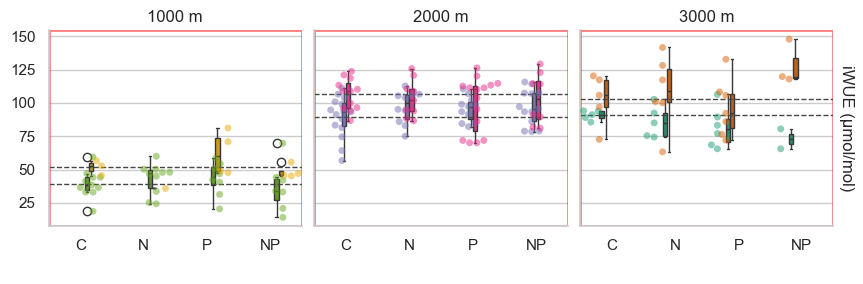

In [ ]:

def create_boxplots(var,data, ax = None):
 import matplotlib.pyplot as plt
 import seaborn as sns
 import pandas as pd
 import matplotlib.patches as patches 


 # Simulación: tu código de melt y orden ya definido antes
 df_long = pd.melt(
    data,
    id_vars=["name", "Sub"],
    value_vars=[var],
    var_name="variable",
    value_name="valor"
  ) 

 # Orden de tratamiento y especies
 orden = ["C", "N", "P", "NP"]
 orden_sp = ["Weinmania  loxensis","Hedyosmun  purpurascens",
            "Myrcia sp nov","Alchornea lojaensis",
            "Pouteria torta","Clarisia  racemosa"]

 df_long["Sub"] = pd.Categorical(df_long["Sub"], categories=orden, ordered=True)
 df_long["name"] = pd.Categorical(df_long["name"], categories=orden_sp, ordered=True)

 # Asignar altitudes según el orden de especies
 altitud_map = {
    "Weinmania  loxensis": "3000",
    "Hedyosmun  purpurascens": "3000",
    "Myrcia sp nov": "2000",
    "Alchornea lojaensis": "2000",
    "Pouteria torta": "1000",
    "Clarisia  racemosa": "1000"
 }
 df_long["altitud"] = df_long["name"].map(altitud_map)

 # Colores fijos por especie
 palette_species = {
    "Weinmania  loxensis": "#1b9e77",
    "Hedyosmun  purpurascens": "#d95f02",
    "Myrcia sp nov": "#7570b3",
    "Alchornea lojaensis": "#e7298a",
    "Pouteria torta": "#66a61e",
    "Clarisia  racemosa": "#e6ab02"
 }

 # Estilo
 sns.set(style="whitegrid")

 # Figura tamaño A4 reducido
 #figsize_a4 = (5.27, 5.69)

 # Forzar el orden correcto de las altitudes
 orden_alt = ["1000", "2000", "3000"]
 df_long["altitud"] = pd.Categorical(df_long["altitud"], categories=orden_alt, ordered=True)

 g = sns.FacetGrid(
    df_long,
    row="variable",
    col="altitud",
    sharey=True,
    height=3,
    aspect=1,
    margin_titles=True
 )

 # Boxplot por especie
 g.map_dataframe(
    sns.boxplot,
    x="Sub", y="valor", hue="name",
    linewidth=1, palette=palette_species, dodge=True, width=0.4,
 )

 # Swarmplot con mismo color
 g.map_dataframe(
    sns.swarmplot,
    x="Sub", y="valor", hue="name",
    palette=palette_species, alpha=0.5, dodge=True
 )

 for ax, (_, subdata) in zip(g.axes.flat, g.facet_data()):
    if subdata is None or subdata.empty:
        continue
    
    # Cálculo por especie dentro del panel
    for sp in subdata["name"].unique():
        
        # Filtrar datos de la especie y del tratamiento control
        mean_val = subdata[
            (subdata["name"] == sp) & 
            (subdata["Sub"] == "C")
        ]["valor"].mean()
        
        if pd.isna(mean_val):
            continue
        
        # Línea horizontal con color fijo del tratamiento CONTROL
        ax.axhline(
            y=mean_val,
            color="#454747",   # o el color que quieras para C
            linestyle="--",
            linewidth=1
        )


 # Etiquetas
 g.set_axis_labels(" ", "")
 g.set_titles(row_template="{row_name}", col_template="{col_name} m")

 # Ajustar figura
 #g.fig.set_size_inches(figsize_a4)
 g.fig.subplots_adjust(wspace=0.05, hspace=0.3)

 # --- Dibujar cajas de altitud ---
 # Como ahora el orden es fijo, podemos agrupar fácilmente
 altitud_groups = {
    "1000 m": [0],
    "2000 m": [1],
    "3000 m": [2]
 }

 for alt_label, indices in altitud_groups.items():
    for idx in indices:
        ax = g.axes[0][idx]
        ax.add_patch(
            patches.Rectangle(
                (-0.5, ax.get_ylim()[0]),
                len(orden),
                ax.get_ylim()[1] - ax.get_ylim()[0],
                fill=False, lw=2, edgecolor="red", alpha=0.5
            )
        )
 
 return g
 
create_boxplots(iWUE,data,ax=None)

In [ ]:
#ar_traits = [vf1,vf2,vf3]
#graph(var_traits)

# Aunque puede servir para ver ciertas tendencias no me gustas mucho el grafico porque no se aprecia de uno en 1. Mejor los boxplots de abajo.

# GRAFICOS IMPORTANTES

In [ ]:
import create_boxplots_control
%run create_boxplots_control.py

In [ ]:
variables_isotopos = [iWUE, named13C_cellulose] 

isotopos = variables_isotopos
for variable in isotopos: 
 create_boxplots_control(variable,data)

NameError: name 'iWUE' is not defined

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use strippl

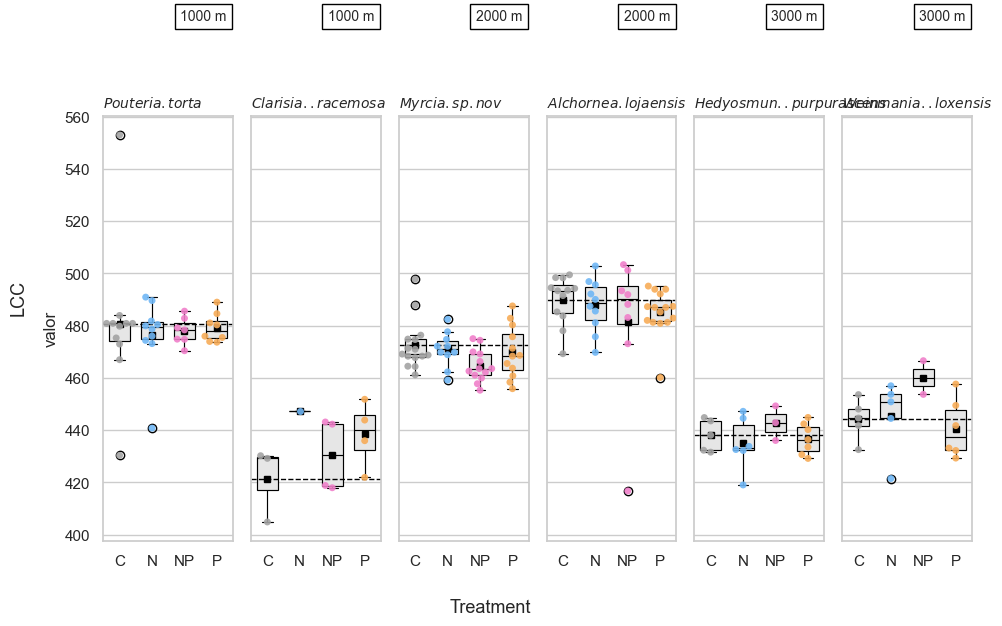

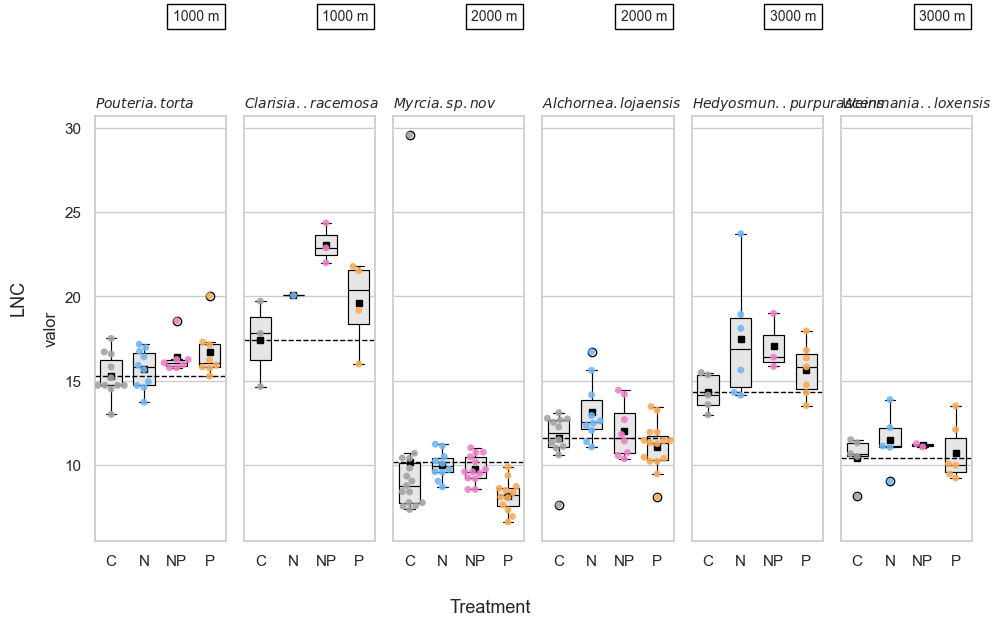

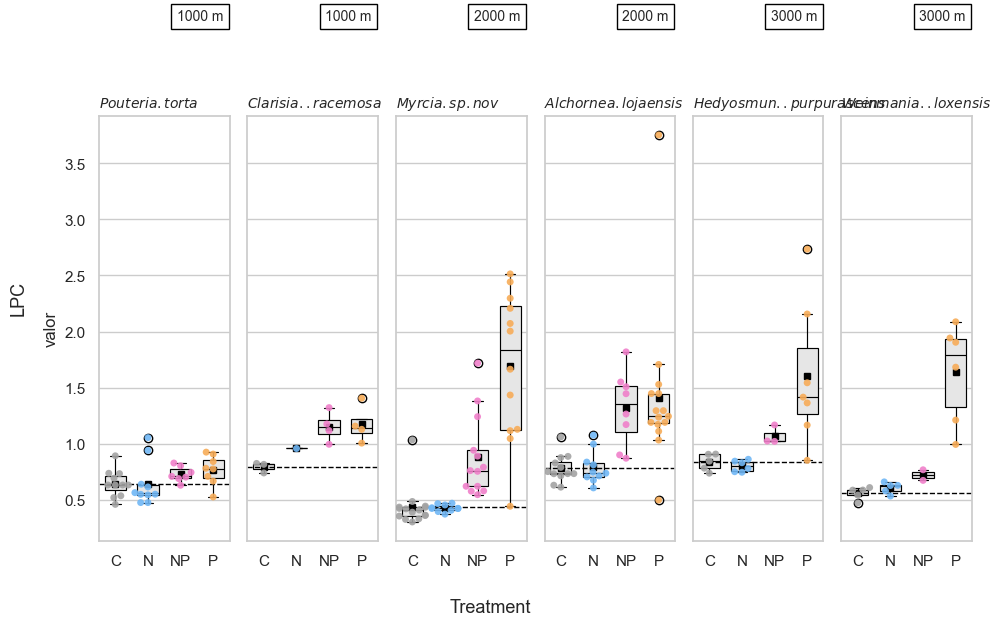

In [ ]:
nutrientes = ["LCC","LNC","LPC"] 
for variable in nutrientes:

 create_boxplots_control(variable,data)

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 27.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 27.3% of the points cannot be placed; you may want to decrease the size of the markers or use strippl

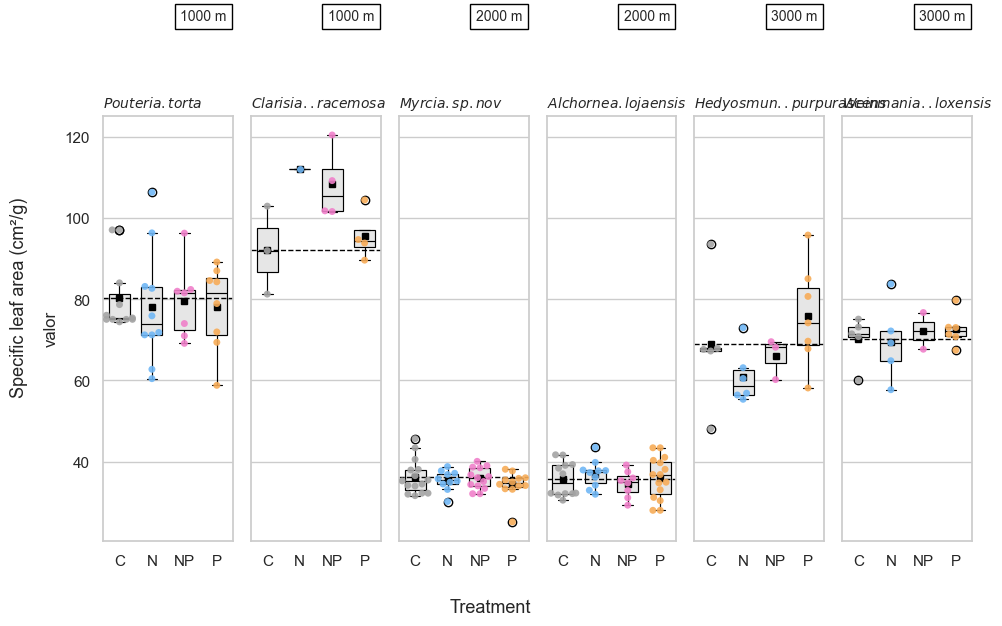

In [ ]:
nutrientes = [SLA] 
for variable in nutrientes:

 create_boxplots_control(variable,data)

In [ ]:
%run kruskal_por_especie_y_tratamiento.py

kruskal_por_especie_y_tratamiento(data, variable=iWUE)



Procesando Especie: Weinmania  loxensis

Total muestras: 18
Comparacion entre tratamientos
C: n = 5
N: n = 5
P: n = 6
NP: n = 2
iWUE (μmol/mol)

TEST KRUSKALL
H = 4.526, p = 0.2100, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 1.296474128105574
P-value: 0.3145016056592404

Procesando Especie: Pouteria torta

Total muestras: 36
Comparacion entre tratamientos
NP: n = 7
P: n = 8
N: n = 10
C: n = 11
iWUE (μmol/mol)

TEST KRUSKALL
H = 2.774, p = 0.4278, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 0.46232731327757726
P-value: 0.7105507750505631

Procesando Especie: Hedyosmun  purpurascens

Total muestras: 21
Comparacion entre tratamientos
P: n = 7
NP: n = 3
C: n = 5
N: n = 6
iWUE (μmol/mol)

TEST KRUSKALL
H = 4.585, p = 0.2049, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 1.5425684898521335
P-value: 0.23985639528737315

Procesando Especie: Clarisia  racemosa

Total muestras: 12
Comparacion entre tratamientos
NP: n = 4
P: n = 4
N: n = 1
C: n = 3
iWUE (μmol/mol)

TEST KRUSKALL
H = 5.000, p = 0.171

[{'H': 4.5263085399449015, 'p': 0.20995559590402574, 'df': 3},
 {'H': 2.774033000363018, 'p': 0.4277924054812482, 'df': 3},
 {'H': 4.584702496983209, 'p': 0.20485831325967638, 'df': 3},
 {'H': 5.0, 'p': 0.1717971442967335, 'df': 3},
 {'H': 2.3030214853516506, 'p': 0.5119423177383426, 'df': 3},
 {'H': 0.6815564048497795, 'p': 0.877533254595053, 'df': 3}]

# modelos

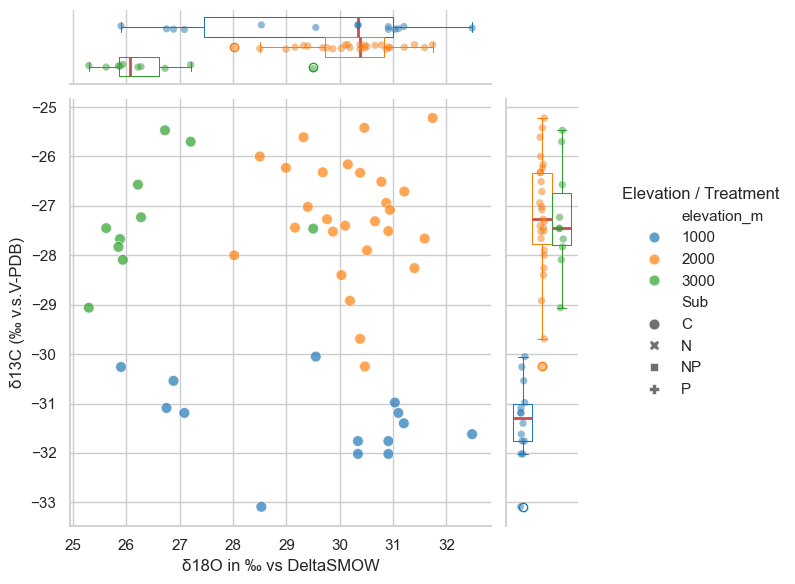

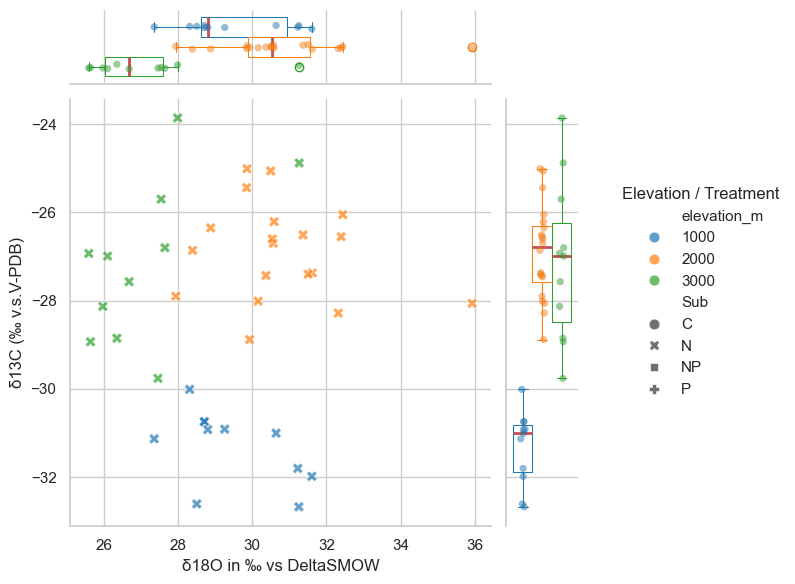

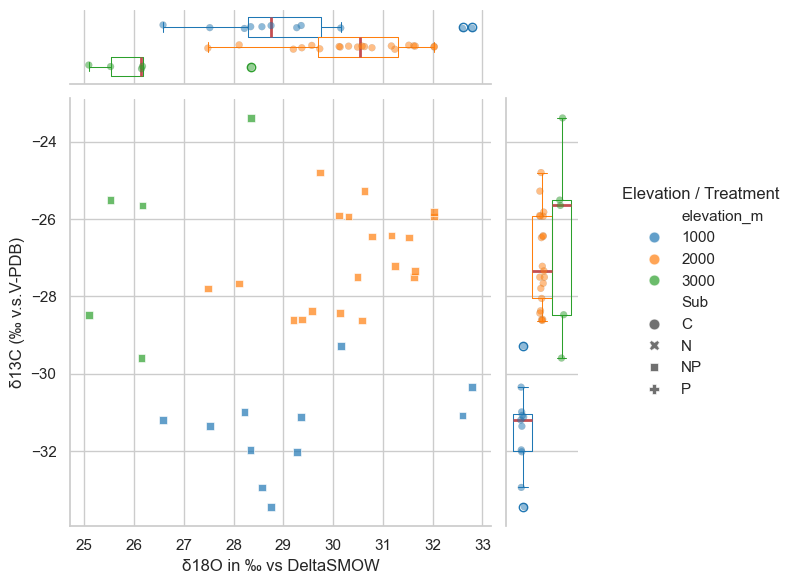

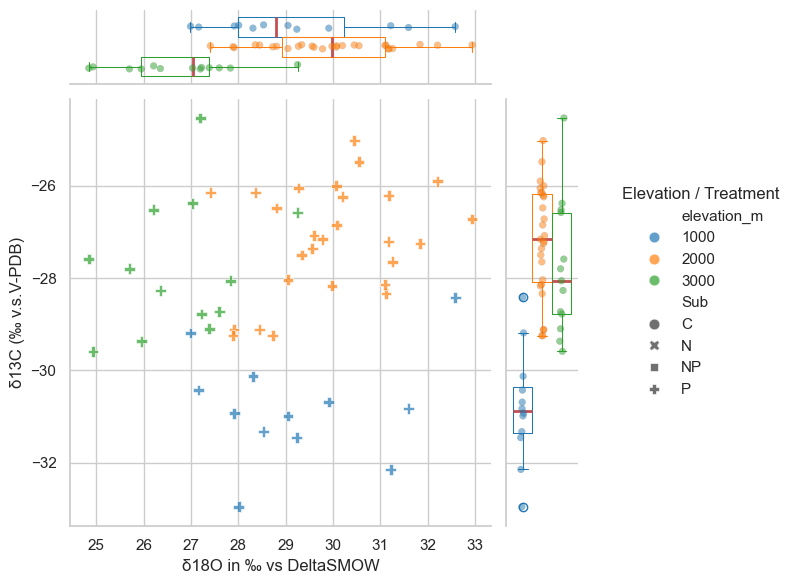

In [ ]:
data_C = data[data["Sub"] == "C"]
data_P = data[data["Sub"] == "P"]
data_NP = data[data["Sub"] == "NP"]
data_N = data[data["Sub"] == "N"]

def plot_d12_d18(data):
 g = sns.JointGrid(data=data, y=named13C_cellulose, x= name18O, hue="elevation_m", palette="tab10")
 g.plot_joint(sns.scatterplot, data=data,          # 👈 CLAVE
    style="Sub",        # o "name" si ese es tu factor
    s=60,
    alpha=0.7)
 g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5)
 g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2})
 g.ax_joint.legend_.remove()
 # ── LEYENDA FUERA ───────────────────────────────
 handles, labels = g.ax_joint.get_legend_handles_labels()

 # crear leyenda externa
 g.fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Elevation / Treatment"
 )

 return g

plot_d12_d18(data_C)
plot_d12_d18(data_N)
plot_d12_d18(data_NP)
plot_d12_d18(data_P)


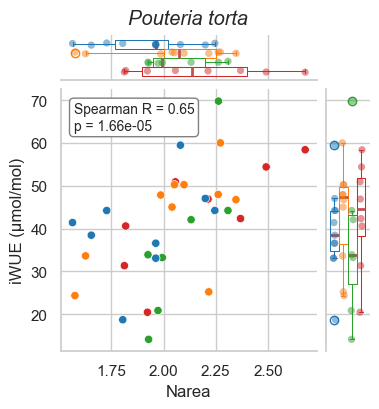

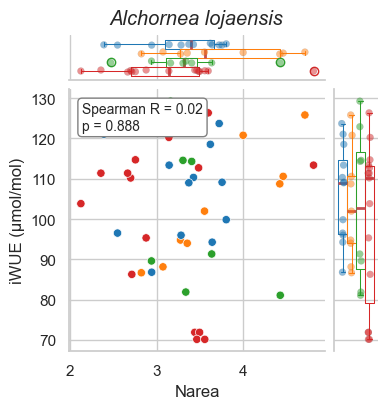

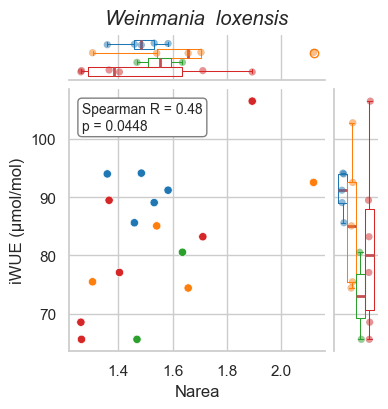

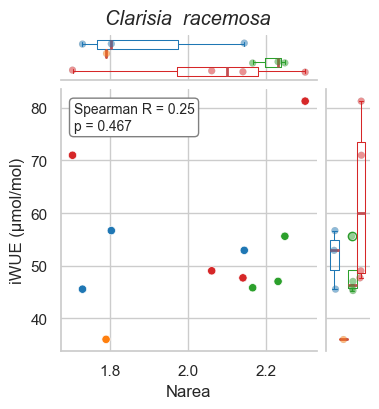

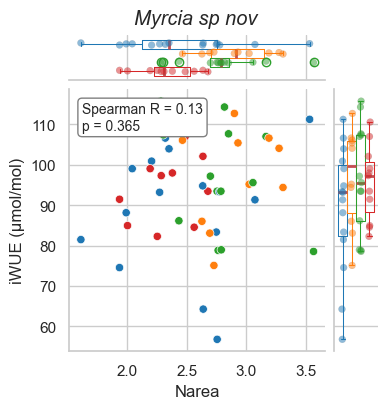

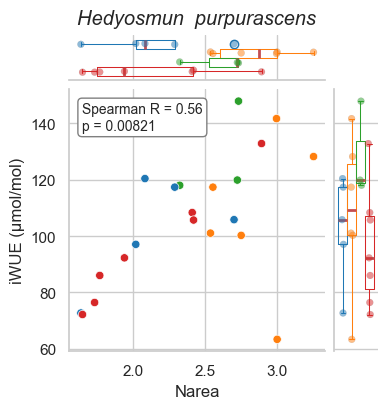

In [ ]:
#Not useful
from scipy.stats import spearmanr

especies = ["Pouteria torta",
  "Alchornea lojaensis",
  "Weinmania  loxensis",
  "Clarisia  racemosa",
  "Myrcia sp nov",
  "Hedyosmun  purpurascens"] #creamos vector especies 
for especie in especies:
    df_name = "df_"+especie
    df_name = data[data["name"]== especie]
    # Spearman (global, sin separar por Sub)
    rho, pval = spearmanr(df_name["Narea"], df_name[iWUE], nan_policy="omit")

    g = sns.JointGrid(data=df_name, x= "Narea", y=iWUE, hue="Sub", palette="tab10",height=4)
    g.plot_joint(sns.scatterplot, legend=False)
    g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5, legend=False)
    g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2},legend=False)
    
    # 📌 Anotación Spearman
    g.ax_joint.annotate(
        f"Spearman R = {rho:.2f}\np = {pval:.3g}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", fc="white", ec="gray")
    )
   
    g.fig.suptitle(especie, y=1.02, style="italic") #

    


### No usar pero crea los codigos en relacion delta 13/ d18O

especies = ["Pouteria torta",
  "Alchornea lojaensis",
  "Weinmania  loxensis",
  "Clarisia  racemosa",
  "Myrcia sp nov",
  "Hedyosmun  purpurascens"] #creamos vector especies 
for especie in especies:
    df_name = "df_"+especie
    df_name = data[data["name"]== especie]
    g = sns.JointGrid(data=df_name, x=vp4, y=vp3, hue="Sub", palette="tab10",height=4)
    g.plot_joint(sns.scatterplot, legend=False)
    g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5, legend=False)
    g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2},legend=False)
    
    g.ax_joint.set_xlim(22, 36)
    g.ax_joint.set_ylim(-22, -36 )
    g.ax_marg_x.set_xlim(25 ,36)
    #g.ax_marg_y.set_ylim(-22, -35)
    mean_x= df_name[df_name["Sub"]=="C"][vp4].mean() 
    mean_y= df_name[df_name["Sub"]=="C"][vp3].mean() 
    g.refline(x=mean_x, y=mean_y) #means of the control
    g.fig.suptitle(especie, y=1.02, style="italic") #

    

| **Pattern**                          | **Interpretation**                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------- |
| Both δ¹³C and δ¹⁸O increase          | Likely due to **reduced stomatal conductance** → both iWUE and leaf water δ¹⁸O increase.    |
| δ¹³C increases but δ¹⁸O does not     | Possibly due to **increased photosynthesis**, not stomatal closure.                         |
| δ¹³C does not increase but δ¹⁸O does | Could indicate **stomatal closure**, but photosynthesis also dropped → no iWUE gain.        |
| No correlation                       | Suggests other processes dominate (e.g., environmental noise, post-photosynthetic effects). |
